In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import yfinance as yf
import seaborn as sns

from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'


# 1. Motivation

Bitcoin is described by some as "digital gold"(Baur et al., 2024), which beyond the obvious mining parallel, implies Bitcoin may share key economic properties with gold as a store of value. 

This project evaluates this hypothesis using high-frequency data (daily closing prices 2015-Current).

* Do Bitcoin and Gold share a long-run equillibirum (are they cointegrated)?
* How does Bitcoin react to broader market stress relative to Gold (represented by VIX index)?
* Is Bitcoin's volatility structure comporable or interestingly related to that of Gold?

# 2. Data

I utilize daily closing prices for Bitcoing (BTC-USD), Gold (GC=F), and the CBOE Volatility Index (^VIX). Data is collected from the yahoo finance API. 

The data spans from 2015-01-01 to the current day (in our case 2026-04-23).

As Bitcoin trades 24/7 and Gold follows market hours, I align dates to overlapping business days. 

I take the logarithm of the price levels for Bitcoin and Gold so that their levels are more comparable. I then compute log returns as: $$ r_t = ln(P_t) - ln(P_t-1), $$ to make respective levels comparable. 

As differencing for returns will make our first observation NaN, I drop NaN values, and our span now encompasses 2015-01-02 to current. 

In [2]:
tickers = ['BTC-USD', 'GC=F', '^VIX']
start_date = '2015-01-01'

raw = yf.download(tickers, start=start_date)['Close']
df = raw[['BTC-USD', 'GC=F', '^VIX']].dropna()

df['log_BTC'] = np.log(df['BTC-USD'])
df['log_GOLD'] = np.log(df['GC=F'])
df['r_BTC'] = df['log_BTC'].diff()
df['r_GOLD'] = df['log_GOLD'].diff()
df = df.dropna()

display(df.head())

[*********************100%***********************]  3 of 3 completed


Ticker,BTC-USD,GC=F,^VIX,log_BTC,log_GOLD,r_BTC,r_GOLD
Date,,,,,,,
2015-01-05,274.473999,1203.900024,19.920000,5.614857,7.093322,-0.137818,0.014980
2015-01-06,286.188995,1219.300049,21.120001,5.656652,7.106032,0.041796,0.012711
2015-01-07,294.337006,1210.599976,19.309999,5.684725,7.098871,0.028073,-0.007161
2015-01-08,283.348999,1208.400024,17.010000,5.646679,7.097052,-0.038046,-0.001819
2015-01-09,290.407990,1216.000000,17.549999,5.671287,7.103322,0.024607,0.006270


# 3. Exploratory Data Analysis

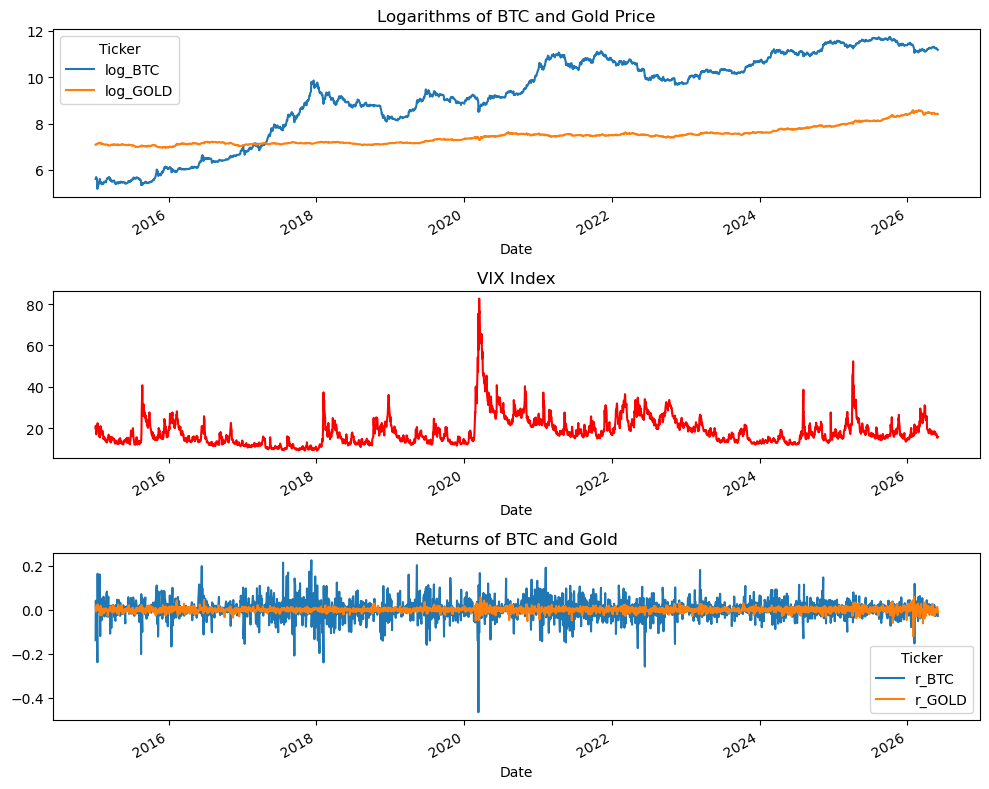

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
df[['log_BTC','log_GOLD']].plot(ax=ax[0], title='Logarithms of BTC and Gold Price')
df['^VIX'].plot(ax=ax[1], title='VIX Index', color='red')
df[['r_BTC','r_GOLD']].plot(ax=ax[2], title='Returns of BTC and Gold')
plt.tight_layout()
plt.show()

In plotting our transformed data, we can see that return variation in Bitcoin appears inversely reflect macro-sentiment proxied by the VIX. Gold appears to respond to macro-volatility, but in far smaller scale. 

### Summary Statistics

In [4]:
cols = ['BTC-USD', 'GC=F', 'log_BTC', 'log_GOLD', 'r_BTC', 'r_GOLD', '^VIX']

summary_stats = df[cols].agg(['count', 'mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T
summary_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis']
summary_stats = df[cols].agg(['count', 'mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T
summary_stats.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis']

styled_table = (
    summary_stats.style
    .format(precision=4, thousands=",")
    .set_properties(**{'background-color': '#ffffff', 'color': '#333333', 'border-color': '#e0e0e0'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), 
            ('color', 'white'), 
            ('font-family', 'sans-serif'),
            ('font-size', '13px'),
            ('padding', '10px')
        ]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'), 
            ('font-size', '16px'), 
            ('font-weight', 'bold'),
            ('margin-bottom', '10px'),
            ('color', '#2c3e50')
        ]}
    ])
    .apply(lambda x: ['background-color: #fff3f3' if v > 3 else '' for v in x], subset=['Kurtosis'])
    .set_caption("Descriptive Statistics")
)

display(styled_table)


,N,Mean,Std Dev,Min,Max,Skewness,Kurtosis
Ticker,,,,,,,
BTC-USD,"2,865.0000","29,314.1201","32,533.7667",178.1030,"124,752.5312",1.1442,0.2268
GC=F,"2,865.0000","1,878.9104",861.6100,"1,050.8000","5,318.3999",1.9445,3.5586
log_BTC,"2,865.0000",9.2189,1.8668,5.1824,11.7341,-0.6706,-0.6988
log_GOLD,"2,865.0000",7.4603,0.3710,6.9573,8.5789,1.0706,0.6252
r_BTC,"2,865.0000",0.0019,0.0420,-0.4647,0.2251,-0.6178,9.6850
r_GOLD,"2,865.0000",0.0005,0.0104,-0.1207,0.0591,-0.7344,9.8855
^VIX,"2,865.0000",18.3847,7.0461,9.1400,82.6900,2.6135,13.2979


Our summary statistics show that Bitcoin and Gold Returns both exhibit high kurtosis. The distribution of BTC and Gold returns can be implied to be dominated by outliers. The negative skewness in the returns of both assets suggest that large movements are typically in the downward direction (potentially reinforcing the idea that they respond to negative market sentiment). The high kurtosis and positive skew of the VIX implies that market fear is typically stable, but infrequently explodes upwards. 

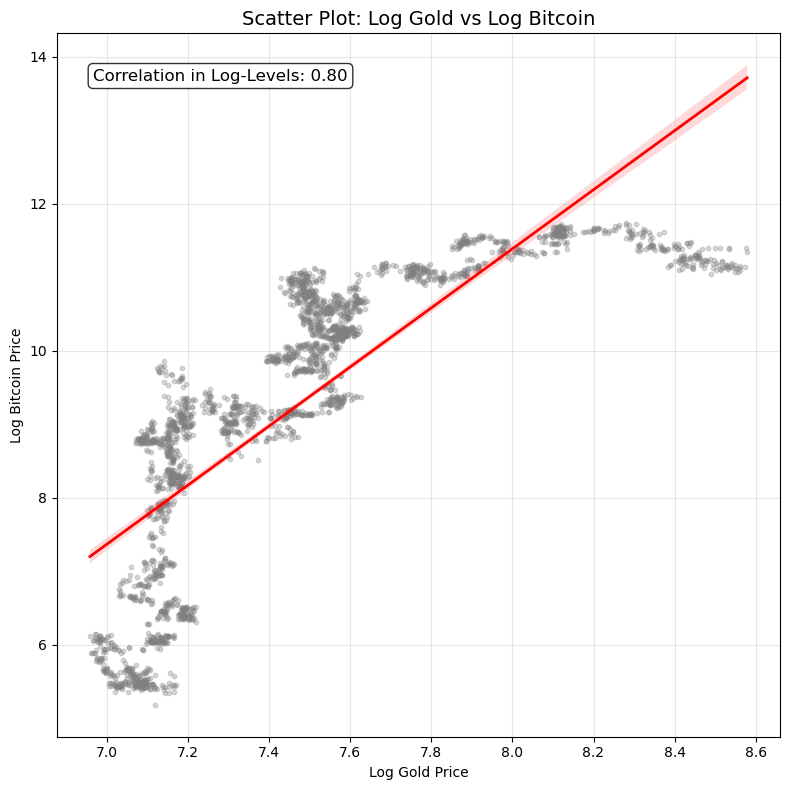

In [5]:
plt.figure(figsize=(8, 8))

sns.regplot(x=df['log_GOLD'], y=df['log_BTC'], 
            scatter_kws={'alpha':0.3, 'color':'gray', 's': 10}, 
            line_kws={'color':'red', 'linewidth': 2})

plt.title('Scatter Plot: Log Gold vs Log Bitcoin', fontsize=14)
plt.xlabel('Log Gold Price')
plt.ylabel('Log Bitcoin Price')

corr = df['log_BTC'].corr(df['log_GOLD'])
plt.text(0.05, 0.95, f'Correlation in Log-Levels: {corr:.2f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot of the log-prices of Gold and Bitcoin suggest strong positive co-movment. The residuals however, do not appear stable. We could speculatively infer that the two assets trend together over macro cycles, but the relationship is clearly non-linear. 

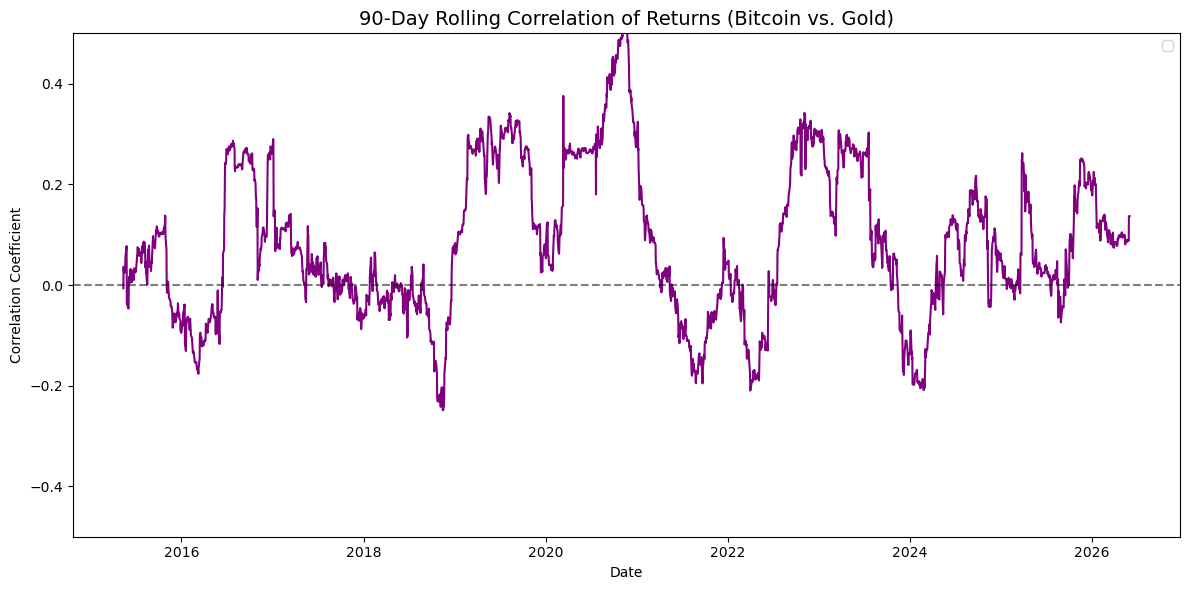

In [6]:
window = 90
df['Rolling_Corr'] = df['r_BTC'].rolling(window=window).corr(df['r_GOLD'])

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Rolling_Corr'], color='purple', linewidth=1.5)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.title('90-Day Rolling Correlation of Returns (Bitcoin vs. Gold)', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.xlabel('Date')
plt.ylim(-0.5, 0.5)


plt.legend()

plt.tight_layout()
plt.show()

Plotting a 90 day rolling correlation of returns, reveals an stochastic and seemingly mean reverting process. The lack of sustained trend in coupling suggests that the correlation of the assets is driven by regime factors. 

# 4. Unit Root Tests

I test for unit roots using the Augmented Dickey-Fuller (ADF) test, where the null hypothesis is Non-Stationarity.

In [7]:
def adf(series, name):
    res = adfuller(series, autolag='AIC')

for col in ['BTC-USD', 'GC=F', 'r_BTC', 'r_GOLD']:
    res = adfuller(df[col])
    print(f"ADF p-value for {col}: {res[1]:.4f}")

ADF p-value for BTC-USD: 0.6935
ADF p-value for GC=F: 0.9986
ADF p-value for r_BTC: 0.0000
ADF p-value for r_GOLD: 0.0000


Log prices fail to reject the null, consistent with $I(1)$ processes. Returns reject the null, indicating stationarity after differencing.

# 5. Autocorrelation Functions and ARIMA Identification

I examine ACFs to suggest (p, d, q) parameters.

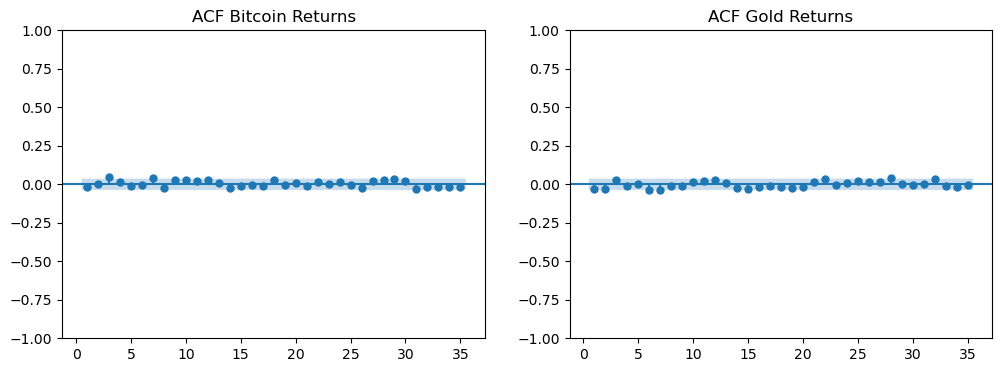

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['r_BTC'], ax=axes[0], zero=False, title='ACF Bitcoin Returns')
plot_acf(df['r_GOLD'], ax=axes[1], zero=False, title='ACF Gold Returns')
plt.show()

The ACF plot for both BTC and Gold returns spikes at lag 0, and then drops into the 95% confidence interval for all lags to follow. Some lags barely escape the confidence interval, but their correlations are low and patterns aren't clear. We can infer these "significant" lags to be artifacts of noise.

We will ignore the significance of lag zero in this and future plots, as an observation at time $t$ will clearly be perfectly correlated with itself. The observation that all lags $t > 0$ fall within the 95% confidence interval implies that the current return of BTC and Gold is not a linear function of past returns (no AR component) and that past innovations do not provide information about current return (no MA component). 

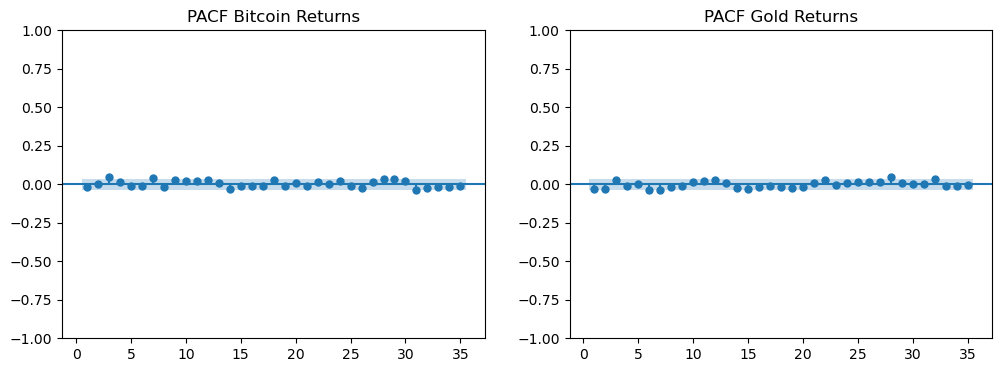

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pacf(df['r_BTC'], ax=axes[0], zero=False, title='PACF Bitcoin Returns')
plot_pacf(df['r_GOLD'], ax=axes[1], zero=False, title='PACF Gold Returns')
plt.show()

Plotting a Partial Autocorrelation Function reveals an effectively identical pattern to that of the ACF, reinforcing our conclusions. The absence of significant autocorrelation beyond lag 0 suggests these series follow a process most similar to a random walk. Mechanically, this implies all past information is priced in to current returns. This result is informative as it suggests despite Bitcoin's high volatility, the price discovery process is similarly as efficient to that of Gold, with no consistently exploitable linear patterns.

While visual diagnostics suggest no exploitable linear dependencies, the standard academic procedure is to estimate a baseline model alongside competing specifications to statistically validate the 'White Noise' hypothesis. To avoid overfitting, we must primarily use a ARIMA(0,0,0) model. I will also use an ARIMA(1,0,1) model to attempt to capture lingering short-term momentum as a robustness check. 

**Note: Our ADF test suggests that returns are stationary (this is intuitive as returns are the first difference of the prices). As a result, we need not apply any differencing in the $d$ parameter of ARIMA.**

# 6. ARIMA Estimation

Competing models are estimated and compared using information criteria.

In [10]:
white_noise_BTC = ARIMA(df['r_BTC'], order=(0,0,0)).fit()
white_noise_GOLD = ARIMA(df['r_GOLD'], order=(0,0,0)).fit()
robust_BTC = ARIMA(df['r_BTC'], order=(1,0,1)).fit()
robust_GOLD = ARIMA(df['r_GOLD'], order=(1,0,1)).fit()

print(f"ARIMA(0,0,0) BIC: {white_noise_BTC.bic:.2f}")
print(f"ARIMA(1,0,1) BIC: {robust_BTC.bic:.2f}")
print(f"ARIMA(0,0,0) BIC: {white_noise_GOLD.bic:.2f}")
print(f"ARIMA(1,0,1) BIC: {robust_GOLD.bic:.2f}")

resid = white_noise_BTC.resid
lb_test = acorr_ljungbox(resid, lags=[35], return_df=True)
resid_gold = white_noise_GOLD.resid
lb_test_gold = acorr_ljungbox(resid_gold, lags=[35], return_df=True)

print("\nLjung-Box Q-Statistice for ARIMA(0,0,0) Residuals:")
print(lb_test)

print("\nLjung-Box Q-Statistice for ARIMA(0,0,0) Residuals (GOLD):")
print(lb_test_gold)


ARIMA(0,0,0) BIC: -10021.13
ARIMA(1,0,1) BIC: -10005.66
ARIMA(0,0,0) BIC: -18040.91
ARIMA(1,0,1) BIC: -18027.80

Ljung-Box Q-Statistice for ARIMA(0,0,0) Residuals:
      lb_stat  lb_pvalue
35  46.814519   0.087485

Ljung-Box Q-Statistice for ARIMA(0,0,0) Residuals (GOLD):
      lb_stat  lb_pvalue
35  45.471745   0.110693


The Bitcoin BIC value for the ARIMA(0,0,0) model is 15 units lower than that of the ARIMA(1,0,1). As more negative values are better in the context of BIC, we can infer the zero'd out model provides superior fit with regards to number of parameters. 

To further validate, I run a Ljung-Box test on the residuals corresponding to the lag lengths in ACF and PACF plots. At 35 lags, we find a p-value of 0.0957. Factoring in the presence of sporatic and  negligibly correlated lags in the ACF and PACF plots, we may deduce that these "significant residuals" indistinguishable from white noise. This confirms that the return series for both assets are linearly efficient, and that ARIMA(0,0,0) is the correct specification. 

While the Ljung-Box test at 35 lags confirms the absence of systematic linear trends, the existence of marginal rejections at shorter lags, in concert with the visible clustering of volatility in our returns plots, suggest that the error term for BTC and Gold may not be independently and identically distributed. Therefore, we proceed to test for ARCH effects. We shift to a Generalized Autoregressive Conditional Heteroskedasticity framework to attempt to capture the risk dynamics of Bitcoin and Gold. 

# 7. GARCH Modeling

Before estimating a GARCH model, we must test for the presence of ARCH characteristics using the Lagrange Multiplier test on the squared residuals of the ARIMA(0,0,0) model. 

In [11]:
lm_stat, p_val, f_stat, f_pval = het_arch(white_noise_BTC.resid)

print(f"ARCH-LM Test Statistic: {lm_stat:.4f}")
print(f"ARCH-LM p-value: {p_val:.4f}")

ARCH-LM Test Statistic: 72.0021
ARCH-LM p-value: 0.0000


In [12]:
lm_stat, p_val, f_stat, f_pval = het_arch(white_noise_GOLD.resid)

print(f"ARCH-LM Test Statistic: {lm_stat:.4f}")
print(f"ARCH-LM p-value: {p_val:.4f}")

ARCH-LM Test Statistic: 224.5605
ARCH-LM p-value: 0.0000


The ARCH-LM test reveals that statistically significant presence of ARCH effects. This implies that we cannot predict the price or returns of BTC and Gold, but we may be able to predict the magnitude of volatility of prices and returns based on prior volatility patterns. Naturally, we transition to specifying a GARCH model. 

We attempt to correctly identify the order of our GARCH estimator by analyzing the squared residuals from our ARIMA(0,0,0) specification. 

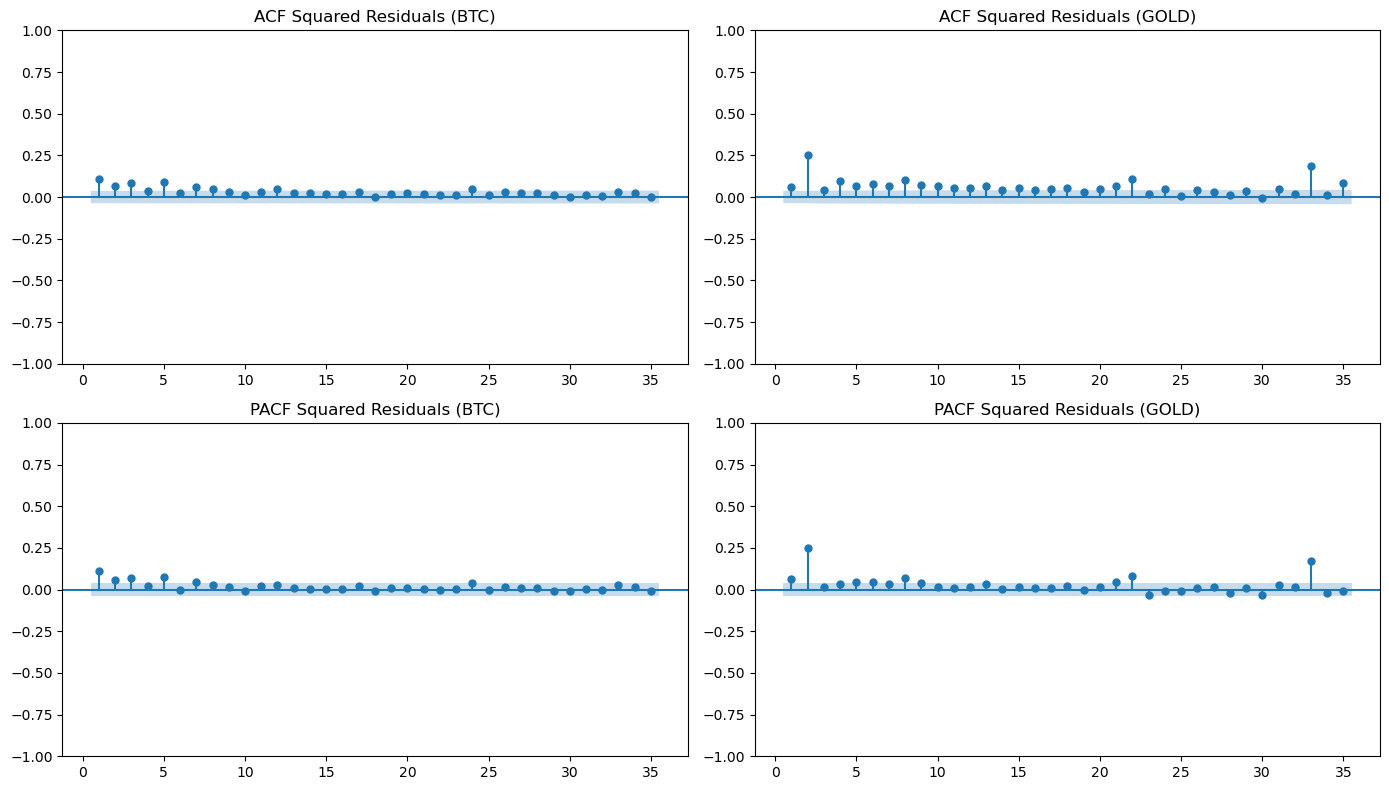

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(white_noise_BTC.resid**2, ax=ax[0, 0], zero=False, title='ACF Squared Residuals (BTC)')
plot_pacf(white_noise_BTC.resid**2, ax=ax[1, 0], zero=False, title='PACF Squared Residuals (BTC)')

plot_acf(white_noise_GOLD.resid**2, ax=ax[0, 1], zero=False, title='ACF Squared Residuals (GOLD)')
plot_pacf(white_noise_GOLD.resid**2, ax=ax[1, 1], zero=False, title='PACF Squared Residuals (GOLD)')

plt.tight_layout()
plt.show()

In analyzing the respective ACF and PACF plots of squared residuals, we find see some small, but consistent and degrading correlation up until lag 6 of BTC. This would suggest BTC volatility is driven primarily by recent price shocks. Interestingly, Gold exhibits a dominant lag spike above 0.25 at lag 2 and other significant correlations at 22 and 33. This provides qualitative evidence of bidaily and calendar effects which could be extrapolated to be associated with monthly futures contract expirations or institutional rebalancing. 

Departing from qualitative analysis, we must acknowledge that the lag structure makes it difficult to find a definitely best parameter specification for GARCH. I perform a grid search for GARCH specifications, to avoid speculative parameterizations. 

In [14]:
def garch_grid_search_10(data, label):
    results = []
    for p in range(1, 35):
        for q in range(1, 35):
            try:
                model = arch_model(data, vol='Garch', p=p, q=q, dist='normal', mean='zero')
                res = model.fit(disp='off', show_warning=False)
                
                results.append({
                    'p': p,
                    'q': q,
                    'BIC': res.bic,
                    'AIC': res.aic,
                    'Converged': res.convergence_flag == 0
                })
            except:
                continue
                
    df = pd.DataFrame(results)
    return df.sort_values('BIC')

btc_garch_grid = garch_grid_search_10(white_noise_BTC.resid, "BTC")
gold_garch_grid = garch_grid_search_10(white_noise_GOLD.resid, "GOLD")

print("Top 3 BTC Specifications by BIC:")
print(btc_garch_grid.head(3))

print("\nTop 3 GOLD Specifications by BIC:")
print(gold_garch_grid.head(3))

Top 3 BTC Specifications by BIC:
    p  q           BIC           AIC  Converged
70  3  3 -10475.372632 -10517.094897       True
1   1  2 -10474.761091 -10498.602385       True
0   1  1 -10473.095767 -10490.976738       True

Top 3 GOLD Specifications by BIC:
    p  q           BIC           AIC  Converged
0   1  1 -18493.924249 -18511.805220       True
34  2  1 -18493.862511 -18517.703805       True
35  2  2 -18479.923000 -18509.724618       True


In our grid search, we find that the best GARCH specification (by BIC) for Bitcoin is a (3,3) model. This implies that variance in time $t$ is best specified by the last three lags of shocks and realized variance. This is somewhat consistent with what we can visually identify in the ACF and PACF plots of squared residuals. 

For Gold, our best specification (by AIC) is a (2,1) model, but is almost statistically indistinguishable in quality from the (1,1) model when we apply the BIC parameter penalty. 

With the optimal lag structures identified via grid search, we proceed to fit the models using maximum likelihood estimation. The objective of this fitting process is to 'whiten' the residuals. If our specifications are valid, our standardized residuals should exhibit no further heteroskedasticity. 

Models are estimated using MLE. The $\omega$ coefficient represents baseline volatility, the $\alpha$ coefficient represents the impact of recent shocks, whiles the $\beta$ coefficient represents volatility persistence. 

In [15]:
#scale by 100 to improve convergence as small floating point operations are tough for optimizer
garch_BTC = arch_model(df['r_BTC']*100, vol='Garch', p=3, q=3, mean='zero')
res_BTC = garch_BTC.fit(disp='off')
print(res_BTC.summary())

# Fit the GOLD GARCH(2,1)
garch_GOLD = arch_model(df['r_GOLD']*100, vol='Garch', p=2, q=1, mean='zero')
res_GOLD = garch_GOLD.fit(disp='off')
print(res_GOLD.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                  r_BTC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7933.15
Distribution:                  Normal   AIC:                           15880.3
Method:            Maximum Likelihood   BIC:                           15922.0
                                        No. Observations:                 2865
Date:                Mon, Jun 01 2026   Df Residuals:                     2865
Time:                        15:35:08   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          2.3502      0.815      2.883  3.943e-03    [  

Comparing $\omega$ (baseline volatility) between Bitcoin and Gold, we see that Bitcoin's baseline volatility coefficient is 2.4789 and statistically significant (p-val), whereas Gold's baseline volatility coefficient is 0.0237 and not significant. This implies that Bitcoin is far more intrinsically noisy. 

In comparing the $\alpha$ of BTC and Gold, we Bitcoin has significant lag values at 1 and 3, where Gold only has a significant $\alpha$ in lag 2. This implies Bitcoin reacts to shocks comparatively strongly from lags 1 and 3. Gold is non-responsive to yesterday's shocks, but is reactive to shocks on a 48 hour realization cycle. This somewhat reinforces my theory that gold acts on a delayed basis due to options expiry, but this remains speculative. 

Contrasting $\beta$ between our models, we can see that volatility persistence in Bitcoin is characterized by a 3 (or possibly more) day horizon, as beta[3] (0.5549) is our only significant coefficient. Gold however exhibits a large beta coefficient of 0.9146, indicating extreme volatility persistence. 

As $\alpha + \beta$ approaches 1, we see slower mean reversion and higher volatility persistence. From this we can infer that while shocks to Bitcoin are high in magnitude, the smaller beta term allows for quicker mean reversion. In contrast, Gold expiriences smaller shocks, but as the sum of alpha and beta is above 0.95, we see slow mean reversion. 

GARCH analysis concludes our investigation into the risk dynamics of Bitcoin and Gold. We have established that Bitcoin behaves as a volatile but mean-reverting asset, whilst Gold operates as a less-volatile but high-persistence asset. It is important to note that identifying volatility-risk characteristics within these assets does not reveal if their price paths are fundamentally linked.

To investigate if stationary relationships exists within these disparate price series, we employ cointegration testing to determine if the assets are bound by a long-run equilibirum. 



# 8. Cointegration

As identified earlier, the log-price and return series exhibited unit root behavior and stationary behavior respectively in our ADF test. As returns are mechanically the first difference of price, we can conclude that the log-price series is I(1). We therefore have the theoretical justification to proceed with cointegration testing. 

We use the Engle-Granger approach to look for a stationary linear combination between the assets.

I regress the log-price of Bitcoin on the log-price of Gold to find the cointegrating vector, and then test the residuals for stationarity via ADF. If the residuals are stationary, the series are cointegrated. 

In [16]:
score, p_value, _ = coint(df['log_BTC'], df['log_GOLD'])

print(f'Engle-Granger Cointegration p-value: {p_value:.4f}')

Engle-Granger Cointegration p-value: 0.7647


As our p-value is greater than 0.05, we must gather that Bitcoin and Gold log-prices are driven by uniquely. Bitcoin and Gold do not follow the same long-term equilibrium path. From a theoretical standpoint, one might expect these assets to be tethered together, aas these assets are traditionally tied to "animal spirits" and a shared skepticism of fiat currency stability. 

However, the results suggest these characteristic drivers do not manifest as stable tethers. This divergence may stem from the asset's differing roles in a modern portfolio: while both share a decentralization narrative, Bitcoin is frequently treated as a speculative, high-convexity asset class, whereas Gold remains anchored to arbitrage opportunities and structural currency hedging.  

Consequently, we forgo the implementation of VECM which searches for a long-run equilibrium that our data suggests does not exists. Instead, we move to VAR to analyze the short-run informational flow. This may allow us to investigate how 'animal spirits' (proxied by the VIX), interact with each asset's returns and whether market fear acts as a common catalyst for short-term price discovery.

# 9,10. Vector Autoregression & Granger Causality

In focusing on returns I(0), we can look at "lead-lag" relationships. We begin by looking for the optimal number of lags to include in our VAR. 

In [17]:
#I'll ensure unit-consistency
df['log_VIX'] = np.log(df['^VIX'])
df['r_VIX'] = df['log_VIX'].diff()
df.dropna()

Ticker,BTC-USD,GC=F,^VIX,log_BTC,log_GOLD,r_BTC,r_GOLD,Rolling_Corr,log_VIX,r_VIX
Date,,,,,,,,,,
2015-05-13,236.376999,1218.400024,13.760000,5.465428,7.105294,-0.019834,0.021403,-0.006512,2.621766,-0.007241
2015-05-14,236.929001,1225.400024,12.740000,5.467761,7.111023,0.002333,0.005729,0.036261,2.544747,-0.077019
2015-05-15,237.604996,1225.500000,12.380000,5.470610,7.111104,0.002849,0.000082,0.024859,2.516082,-0.028664
2015-05-18,233.128006,1227.800049,12.730000,5.451588,7.112979,-0.019022,0.001875,0.029113,2.543961,0.027879
2015-05-19,231.947006,1206.900024,12.850000,5.446509,7.095810,-0.005079,-0.017169,0.028264,2.553344,0.009382
...,...,...,...,...,...,...,...,...,...,...
2026-05-26,75825.734375,4500.399902,17.010000,11.236193,8.411922,0.004461,-0.004567,0.087182,2.833801,0.018393
2026-05-27,74344.703125,4447.500000,16.290001,11.216468,8.400097,-0.019725,-0.011824,0.089621,2.790551,-0.043250
2026-05-28,73536.554688,4499.299805,15.740000,11.205538,8.411677,-0.010930,0.011580,0.088260,2.756205,-0.034346


In [18]:
#even though it's likely stationary by construction, let's play it safe
result = adfuller(df['^VIX'].dropna())
print(f'ADF p-value for VIX: {result[1]:.4f}')
result = adfuller(df['r_VIX'].dropna())
print(f'ADF p-value for VIX Returns: {result[1]:.4f}')

ADF p-value for VIX: 0.0000
ADF p-value for VIX Returns: 0.0000


In [19]:
var_data = df[['r_BTC', 'r_GOLD', 'r_VIX']].dropna()

model = VAR(var_data)
x = model.select_order(maxlags=35)
print(x.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.59     -20.59*   1.137e-09     -20.59*
1      -20.60*      -20.57  1.135e-09*      -20.59
2       -20.59      -20.55   1.137e-09      -20.58
3       -20.59      -20.53   1.139e-09      -20.57
4       -20.59      -20.51   1.139e-09      -20.56
5       -20.59      -20.49   1.142e-09      -20.55
6       -20.59      -20.47   1.140e-09      -20.55
7       -20.60      -20.46   1.136e-09      -20.55
8       -20.59      -20.44   1.138e-09      -20.54
9       -20.59      -20.41   1.142e-09      -20.53
10      -20.59      -20.39   1.145e-09      -20.52
11      -20.59      -20.37   1.146e-09      -20.51
12      -20.59      -20.35   1.147e-09      -20.50
13      -20.58      -20.33   1.153e-09      -20.49
14      -20.58      -20.31   1.155e-09      -20.48
15      -20.58      -20.29   1.159e-09      -20.47
16      -20.57      -20.26   1.

To determine the optimal lag structure for our three-variable system, we utilize BIC, Hannan-Quinn Information Criterion, AIC, and Final Prediction Error. BIC and HQIC both suggest a lag of zero, which indicative of highly efficient pricing. AIC and FPE however, suggest a VAR(1) specification, suggesting short-lived but observable potential lead-lag effects. We proceed with the VAR(1) model so that we can attempt to observe how market fear on day $t$ impacts the returns of Bitcoin and Gold in day $t+1$.

In [20]:
var_model = model.fit(1)
print(var_model.summary())

granger_vix_btc = var_model.test_causality('r_BTC', 'r_VIX', kind='f')
print(f"VIX Granger-causes BTC: {granger_vix_btc.pvalue:.4f}")

granger_vix_gold = var_model.test_causality('r_GOLD', 'r_VIX', kind='f')
print(f"VIX Granger-causes Gold: {granger_vix_gold.pvalue:.4f}")

granger_gold_btc = var_model.test_causality('r_BTC', 'r_GOLD', kind='f')
print(f"Gold Granger-causes BTC: {granger_gold_btc.pvalue:.4f}")

granger_btc_gold = var_model.test_causality('r_GOLD', 'r_BTC', kind='f')
print(f"BTC Granger-causes Gold: {granger_btc_gold.pvalue:.4f}")

granger_btc_vix = var_model.test_causality('r_VIX', 'r_BTC', kind='f')
print(f"BTC Granger-causes VIX: {granger_btc_vix.pvalue:.4f}")

granger_gold_vix = var_model.test_causality('r_VIX', 'r_GOLD', kind='f')
print(f"GOLD Granger-causes VIX: {granger_gold_vix.pvalue:.4f}")

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Jun, 2026
Time:                     15:35:10
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.5478
Nobs:                     2863.00    HQIC:                  -20.5638
Log likelihood:           17274.7    FPE:                1.16236e-09
AIC:                     -20.5728    Det(Omega_mle):     1.15750e-09
--------------------------------------------------------------------
Results for equation r_BTC
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.001974         0.000785            2.514           0.012
L1.r_BTC         -0.012110         0.019153           -0.632           0.527
L1.r_GOLD        -0.047886         0.076001           -0.630           0.529

The individual VAR coefficients provide a granular view of the system's informational decay. The self-lag coefficients reveal that while the VIX exhibits strong mean-reverting properties (p<0.001), Bitcoin returns follow a near-stochastic path with no significant serial correlation

Notably, the cross-equation coefficients illustrate divergence in how "Animal Spirits" are processed. The VIX exerts a statistically significant lagged negative impact on Gold returns (-0.0068, p=0.005), identifying Gold as a lagged respondent to macro-shocks. The VIX contrastingly shows no lagged predictive power over Bitcoin (p=0.930). When combined with strong contemporaneous correlation found in residuals, this suggests Bitcoin's price discovery is instantaneous, likely bypassing the lead-lag structures (at least at this level of time granularity).

Mechanically, the Granger Causality results suggest a Lead-Lag hierarchy. While traditional theory may suggest that equity-market volatility (VIX) should drive speculative assets, the VIX fails to provide any lagged predictive power for Bitcoin returns (p=0.93). This suggests that Bitcoin prices fear shocks with sufficient velocity so that as the VIX's daily closing price is recorded, the information has already been fully absorbed. This asymmetry implies that "Animal Spirits" manifest in high-velocity assets like bitcoin instantaneously.

Beyond the lead-lag dynamics, the residual correlation matrix identifies significant contemporaneous link between Bitcoin and the VIX (-0.199). The combination of a strong immediate correlation and lack of lagged predictability suggests that Bitcoin does not follow traditional market fear in delayed fashion, but rather is a real-time proxy for the VIX itself. This relation ship likely stems from Bitcoin's superior granularity in price discovery. 

In contrast, Gold's relationship with the VIX is structurally delayed. This is evidenced by the statistically significant lagged coefficient (-0.0068, p=0.005) which confirms that Gold acts as a slow respondent to macro-volatility. 

To move beyond a static map of 'who predicts who', to more dynamic models, we progress to Impulse Response Functions. This will allow use to simulate an exogenous innovation and analyze the shock's effects. By testing multiple structural ordering with Recursive VARs, we may isolate whether 'Animal Spirits' are processed rapidly by assets like Bitcoin or whether they exert more persistent structural influence.

# 11. Impulse Response Functions

To ensure our results aren't an artifact or ordering or assumptions, we implement three progressions within our impulse response modeling. The first being Reduced-Form IRF, where we treat every variable as if it's shocks are independent. 

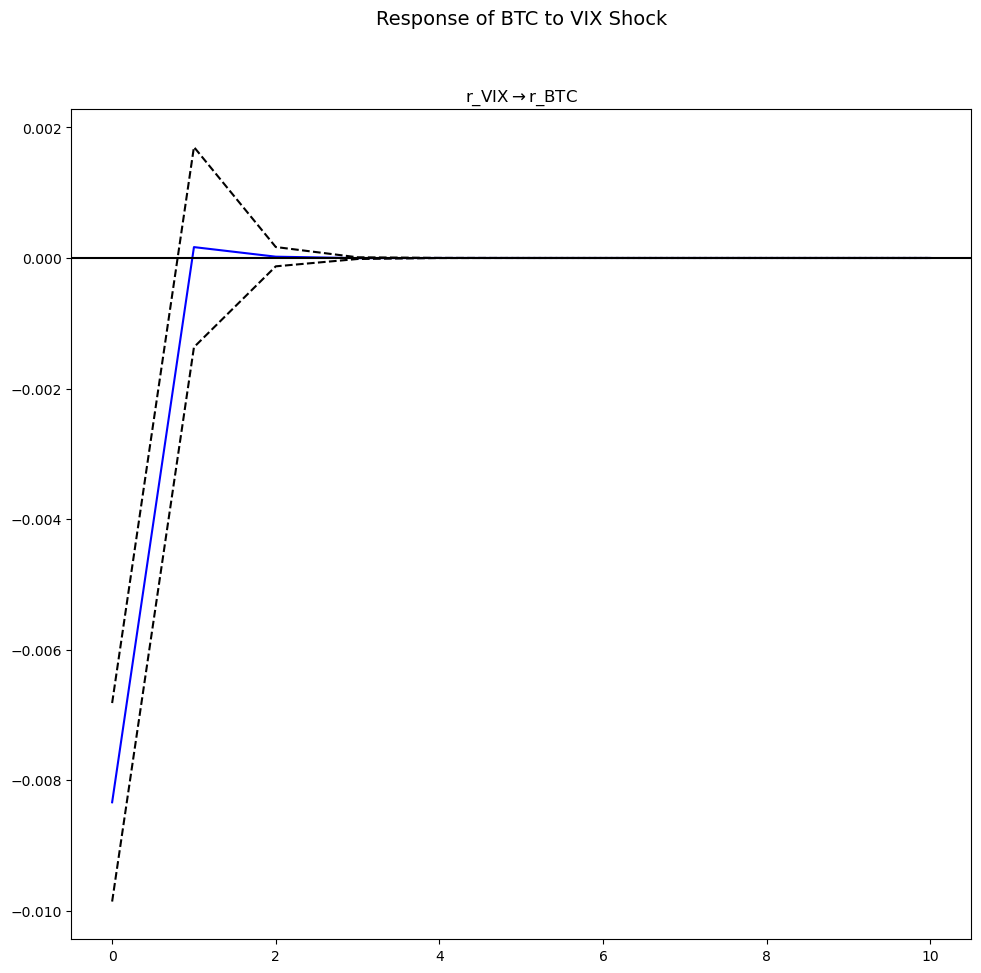

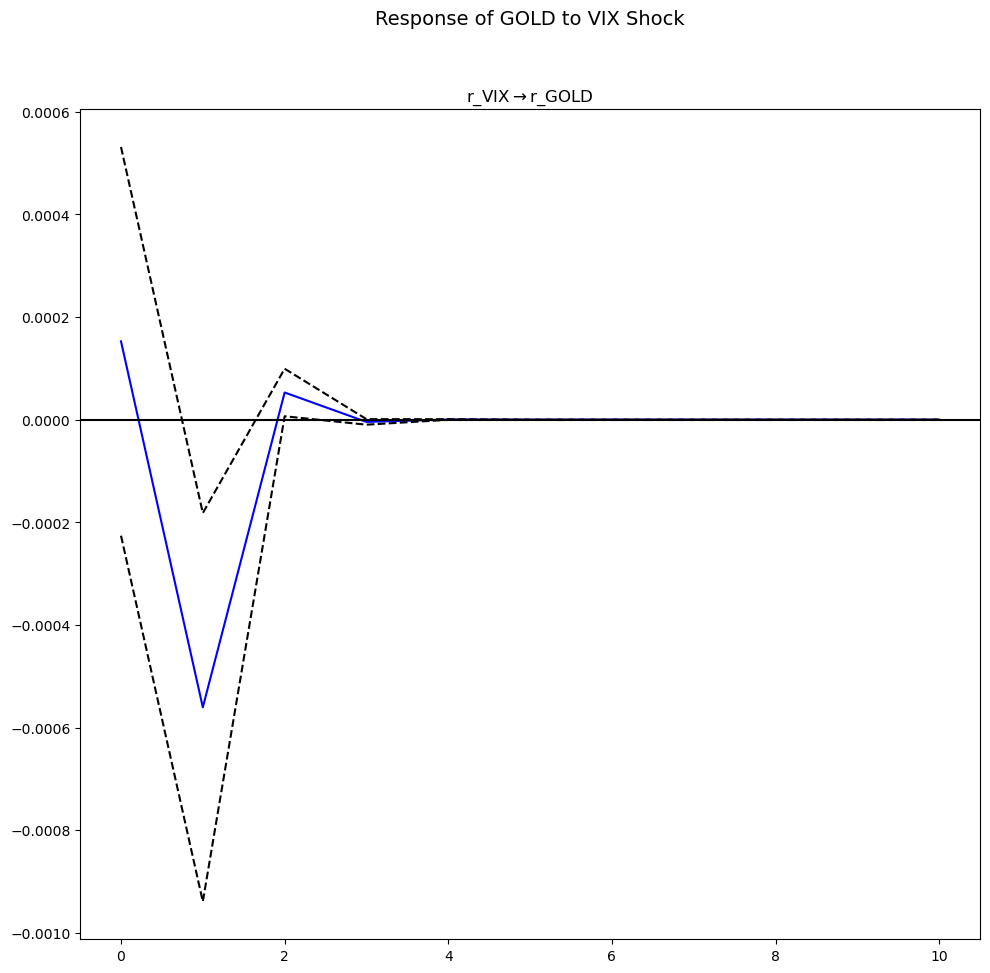

In [21]:
order_1 = ['r_VIX', 'r_BTC', 'r_GOLD']
order_2 = ['r_BTC', 'r_VIX', 'r_GOLD']

var_data_1 = df[order_1].dropna()
var_data_2 = df[order_2].dropna()

results_1 = VAR(var_data_1).fit(1)
results_2 = VAR(var_data_2).fit(1)

irf_1 = results_1.irf(10)
irf_2 = results_2.irf(10)


fig1 = irf_1.plot(impulse='r_VIX', response='r_BTC', orth=True)
fig1.suptitle('Response of BTC to VIX Shock', fontsize=14)
plt.subplots_adjust(top=0.88)

fig2 = irf_1.plot(impulse='r_VIX', response='r_GOLD', orth=True)
fig2.suptitle('Response of GOLD to VIX Shock', fontsize=14)
plt.subplots_adjust(top=0.88)



We introduce a positive one standard deviation innovation (irf(10)) into the impulse variable's error term. We then observe the response variable's movement. 

In IRF 1 (Response of BTC to VIX), the innovation triggers and immediate and sharp expansion of the 95% CI, with a negative response bounded between -0.007 and -0.010. This response however, exhibits rapid decay, converging to equilibrium by Lag 2. This suggests that while Bitcoin is highly sensitive to exogenous VIX shocks, it absorbs and dissipates macro-fear rapidly. 

In contrast, IRF2 (Response of Gold to VIX) shows a delayed reaction. On Lag 0, the response is negligible and lacks directional clarity (maybe a slight positive skew which is theoretically consistent with Gold being an alternative store of value). Significant negative pressure only manifests at lag 1, followed by a gradual rebound through lag 3, with convergence at lag 4. This supports the hypothesis that Gold is a slow responder.

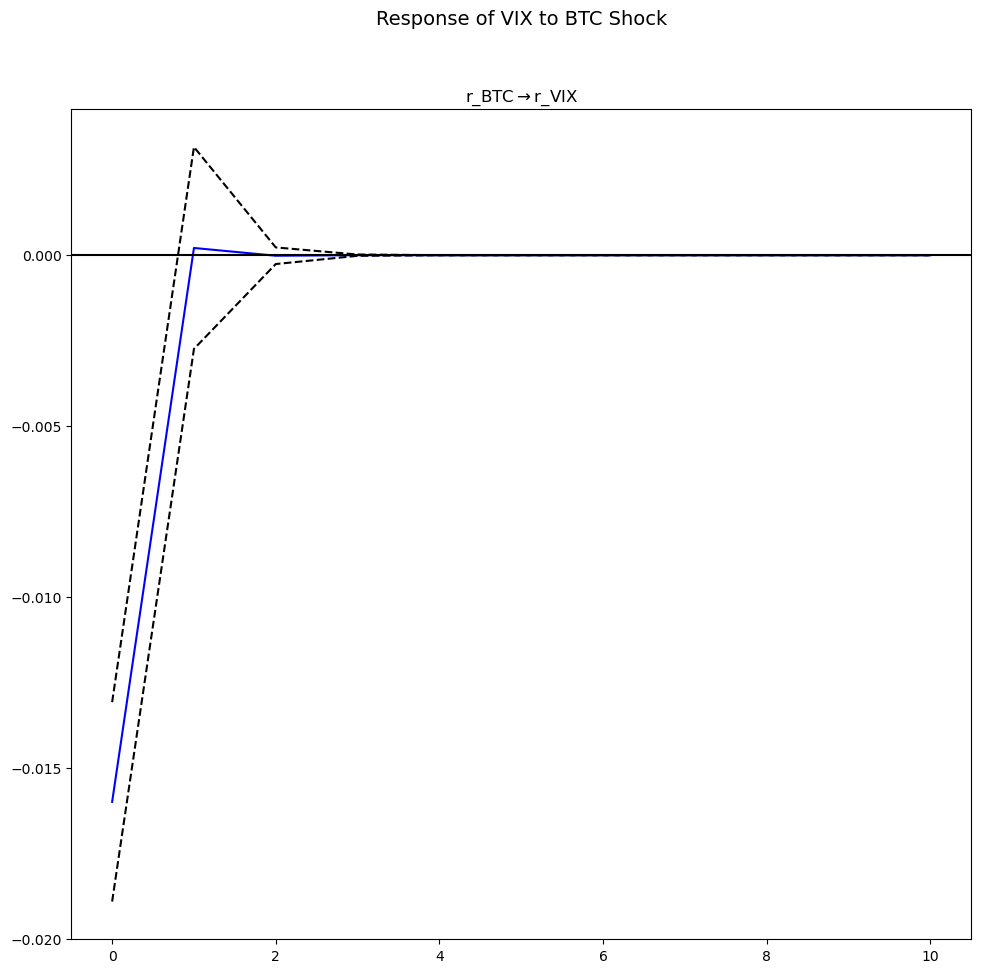

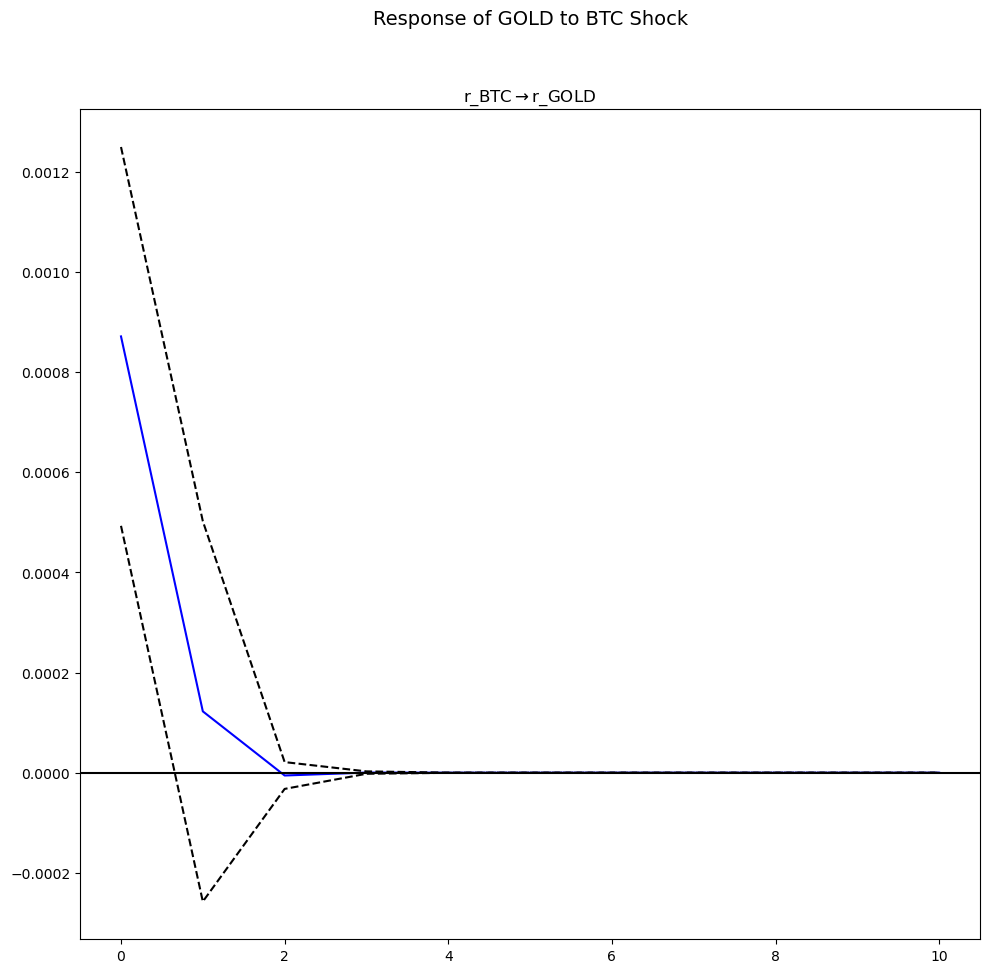

In [22]:
fig3 = irf_2.plot(impulse='r_BTC', response='r_VIX', orth=True)
fig3.suptitle('Response of VIX to BTC Shock', fontsize=14)
plt.subplots_adjust(top=0.88)

fig4 = irf_2.plot(impulse='r_BTC', response='r_GOLD', orth=True)
fig4.suptitle('Response of GOLD to BTC Shock', fontsize=14)
plt.subplots_adjust(top=0.88)

For these specifications, we initially utilize a recursive ordering of (VIX → BTC → GOLD), assuming traditional macro-dominance. However, the results of IRF 3 (Response of VIX to BTC) present a striking symmetry to the inverse (VIX → BTC). This identical shock-decay profile suggests a unified volatility regime where market fear is processed with equal velocity across both the VIX and Bitcoin.

To resolve this symmetry and determine the "first mover", we rely on our Granger Causality results. Given that Bitcoin significantly predicts the VIX (p=0.0051) while the VIX fails to provide predictive power for Bitcoin (p=0.93), the reordering to (BTC->VIX->Gold) is logical. This adjustment confirms that identified symmetry is not mutual dependence, but suggests Bitcoin serves as a low-latency conduit through which "Animal Spirits" enter the market; the VIX simply reflects the resulting equilibrium shift. 

Our forth IRF (Response of Gold to BTC) further elucidates this hierarchy, contrasting the inverse relationship observed between VIX and Bitcoin. A positive one standard deviation shock in Bitcoin leads to a rapid and significant movement in the GOLD CI, with convergence in lag 3. This positive co-movement suggests that Bitcoin does not always function as a fiat alternative, but potentially as a high-beta risky asset. It's price discovery acts as a proxy for "animal spirits", which transmits a secondary shock to Gold. This implies that the "Digital Gold" narrative may be better framed in the light of shared participation liquidity cycles, than a shared defensive hedge profile. 

# 12. Conclusion

Our analysis reveals that Bitcoin functions as a leading indicator of macro-volatility on given the time granularity of the sample. The Granger Causality tests demonstrate that Bitcoin returns significantly predicts shift in the VIX (p=0.0051), while the VIX fails to reciprocate predictive power. 

Our impulse response functions futher distinguish the "Digital Gold" narrative from reality:

* Bitcoin behaves as a rapid sensor, absorbing shocks and stabilizing within 48 hours. 

* Gold remains a delayed respondent, with the confidence interval converging relatively slower than its digital counterpart. 

Applying these findings to a broader context, there is compelling evidence to suggest Bitcoin behaves as a high-frequency conduit for global risk-appetite. Consequently, Bitcoin returns may be a powerful factor in regime classification models. The "Digital Gold" thesis, while supported by occasional co-movements, is secondary to this possible "sentiment conduit" relationship.

This analysis has many limitations, most notably time granularity. Given Bitcoin's 24/7 information stream, moving to intra-day or tick-level data may expose emergent patterns not yet identified. Adding exogenous controls for money supply or real interest rates, could additionally help isolate whether Bitcoins behavior is driven by sentiment or factors such as central bank liquidity. 

It is important to note, that Bitcoin and the VIX likely see significant pairs trading by institutions. This pairs trading if present, is likely partially responsible for zero-day synchronization, as institutional algorithms operate on millisecond scales. The rapid mean reversion we see in our IRFs, may additionally be driven by traders/algorithms exiting their positions, forcing assets back to equilibrium. 

The application of this research topic I am most interested in, lies in it's application to regime identification models. Most regime identification models rely on lagging macroeconomic indicators, realized volatility, or natural language processing. Our findings suggest that it is worth investigating as to whether high-granularity Bitcoin return innovations could serve as high-frequency transition indicators. By using Bitcoin as a leading sensor for the VIX, a model might be able to identify the onset of turbulent regimes faster than most models. 



## 12. Markov Switching Model

In [12]:
tickers = ['BTC-USD', '^IRX']
raw = yf.download(tickers, start='2018-01-01', end='2026-06-01')['Close']
#slice first row as empty
raw = raw.iloc[1:]
#forward fill due to frequency limitations in TBill
raw = raw.asfreq('B')
raw.head()

[*********************100%***********************]  2 of 2 completed


Ticker,BTC-USD,^IRX
Date,,
2018-01-02,14982.099609,1.378
2018-01-03,15201.000000,1.370
2018-01-04,15599.200195,1.370
2018-01-05,17429.500000,1.370
2018-01-08,15170.099609,1.380


In [19]:
#stationarity requirement -> change to levels
raw['btc-ret'] = np.log(raw['BTC-USD']).diff()
raw['delta-yield'] = raw['^IRX'].diff()
raw = raw.asfreq('B')
raw['delta-yield'] = raw['delta-yield'].ffill()
df = raw.iloc[1:]
df.head()

Ticker,BTC-USD,^IRX,btc-ret,delta-yield
Date,,,,
2018-01-03,15201.000000,1.370,0.014505,-0.008
2018-01-04,15599.200195,1.370,0.025858,0.000
2018-01-05,17429.500000,1.370,0.110945,0.000
2018-01-08,15170.099609,1.380,-0.138838,0.010
2018-01-09,14595.400391,1.415,-0.038620,0.035


In [31]:
#collect 2 moments and standardize
mu_btc = df['btc-ret'].mean()
std_btc = df['btc-ret'].std()

mu_tbill = df['delta-yield'].mean()
std_tbill = df['delta-yield'].std()

df['btc-ret-z'] = (df['btc-ret'] - mu_btc) / std_btc
df['delta-yield-z'] = (df['delta-yield'] - mu_tbill) / std_tbill

In [ ]:
#quick stationarity check

def test_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print('Result: Stationary (Reject H0)')
    else:
        print('Result: Non-Stationary (Fail to reject H0)')
    print('\n')

test_stationarity(raw['btc-ret-z'], 'BTC Returns')
test_stationarity(raw['delta-yield-z'], 'Delta Yield')

--- ADF Test for BTC Returns ---
ADF Statistic: -20.7527
p-value: 0.0000
Result: Stationary (Reject H0)


--- ADF Test for Delta Yield ---
ADF Statistic: -6.6677
p-value: 0.0000
Result: Stationary (Reject H0)




In [42]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import statsmodels.api as sm
#Markov Regression
#Order 0: Returns in regime are independent of past values, rather vol clustering
#Order 1: Adding autoregressive component indicating there is some mean-reverting or momentum component indicating fear/greed

y = df['btc-ret-z']
x = df['delta-yield-z']

model = MarkovRegression(
    endog=y,
    k_regimes=2,
    exog=x,
    order = 1,
    switching_variance=True,
    switching_trend=True
)

res = model.fit(disp=True)

print(res.summary())

transition_matrix = res.regime_transition

# 2. State Probabilities
# Filtered probabilities
filtered_probs = res.filtered_marginal_probabilities
# Smoothed probabilities
smoothed_probs = res.smoothed_marginal_probabilities

#Model Parameters
params = res.params
conf_int = res.conf_int() 



Optimization terminated successfully.
         Current function value: 1.284636
         Iterations: 33
         Function evaluations: 35
         Gradient evaluations: 35
                        Markov Switching Model Results                        
Dep. Variable:              btc-ret-z   No. Observations:                 2193
Model:               MarkovRegression   Log Likelihood               -2817.206
Date:                Tue, 09 Jun 2026   AIC                           5650.412
Time:                        16:37:07   BIC                           5695.956
Sample:                    01-03-2018   HQIC                          5667.057
                         - 05-29-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

#### Sigma in stress regime was 2.6 compared to 0.29. We've probably found seperate regimes. Looking at x2 coeff, we see that shocks seem to have a stronger negative impact on bitcoin in S1 then in S0. We can also see that calm regimes are in theory more persistent. 


In [38]:
model_log = {
    'log_likelihood': res.llf,
    'aic': res.aic,
    'transition_p00': transition_matrix[0, 0],
    'transition_p11': transition_matrix[1, 1],
    'regime_0_sigma': res.params['sigma2[0]'],
    'regime_1_sigma': res.params['sigma2[1]']
}

df_log = pd.DataFrame([model_log])
print(df_log)

   log_likelihood          aic        transition_p00       transition_p11  \
0    -2817.206054  5654.412108  [0.8631998553929988]  [0.677369935759326]   

   regime_0_sigma  regime_1_sigma  
0        0.293285        2.652428  


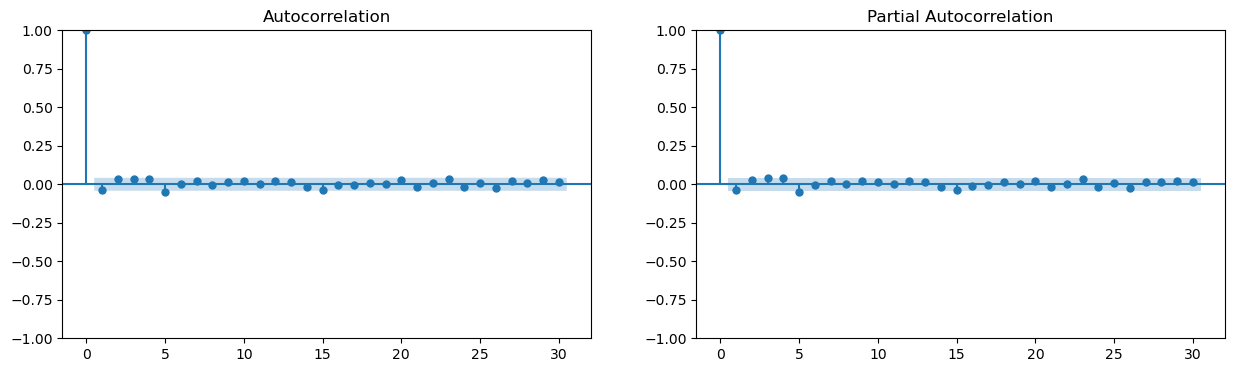

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sm.graphics.tsa.plot_acf(res.resid, lags=30, ax=ax[0])
sm.graphics.tsa.plot_pacf(res.resid, lags=30, ax=ax[1])
plt.show()

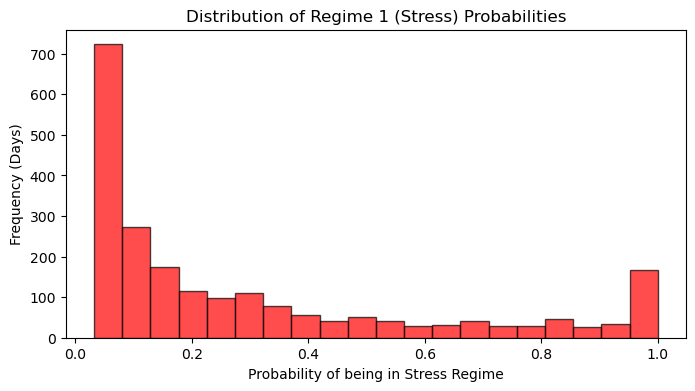

In [44]:
#EDA on confidence and possible correlation with significant macro-events
prob_stress = res.smoothed_marginal_probabilities.iloc[:, 1]

plt.figure(figsize=(8, 4))
plt.hist(prob_stress, bins=20, color='red', alpha=0.7, edgecolor='black')
plt.title("Distribution of Regime 1 (Stress) Probabilities")
plt.xlabel("Probability of being in Stress Regime")
plt.ylabel("Frequency (Days)")
plt.show()

#### Following Kole van Djik, lets implement the MS-VAR as a non-linear Gaussian process to see how the states propogate.

In [46]:
print(res.params.index)

Index(['p[0->0]', 'p[1->0]', 'const[0]', 'const[1]', 'x1[0]', 'x1[1]',
       'sigma2[0]', 'sigma2[1]'],
      dtype='object')


In [ ]:
def simulate_impulse_response(model_results, shock_size=1, horizon=10):
    #x1 is coefficient for delta-yield-z
    #ar.L1 is the autoregressive term
    params = model_results.params
    beta_shock = params['x1[0]']
    ar_coef = params['x1[1]']
    
    #Simulate impact in Regime 0 vs Regime 1
    #See response path for both states
    response_0 = np.zeros(horizon)
    response_1 = np.zeros(horizon)
    
    #shock
    response_0[0] = beta_shock
    response_1[0] = beta_shock
    
    # Propagation over time
    for t in range(1, horizon):
        response_0[t] = response_0[t-1] * ar_coef
        response_1[t] = response_1[t-1] * ar_coef
        
    return response_0, response_1

res0, res1 = simulate_impulse_response(res)

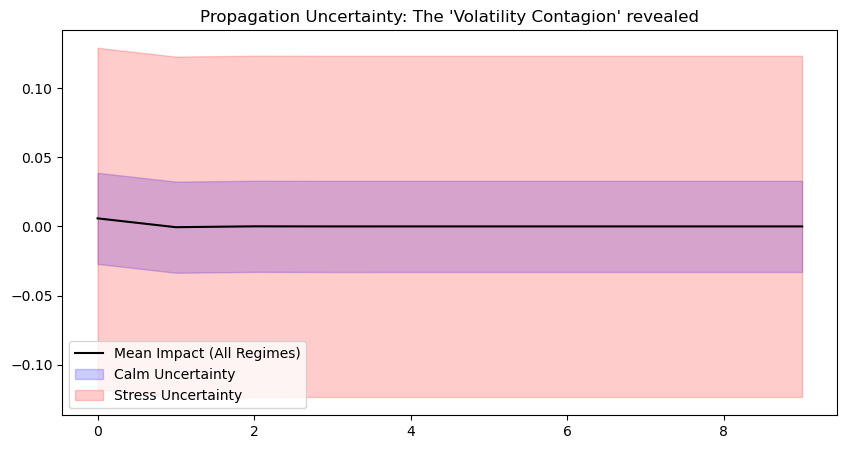

In [ ]:
#std. err
se_calm = res.bse['x1[0]']
se_stress = res.bse['x1[1]']

plt.figure(figsize=(10, 5))

#Mean
plt.plot(res0, label='Mean Impact (All Regimes)', color='black')

#variance
plt.fill_between(range(len(res0)), res0 - 1.96*se_calm, res0 + 1.96*se_calm, color='blue', alpha=0.2, label='Calm Uncertainty')
plt.fill_between(range(len(res1)), res1 - 1.96*se_stress, res1 + 1.96*se_stress, color='red', alpha=0.2, label='Stress Uncertainty')

plt.title("Propagation Uncertainty: The 'Volatility Contagion' revealed")
plt.legend()
plt.show()

### It seems to be that both regimes respond nearly identically to shocks within relevant frame, but the variance between regimes are massive. This implies that regimes identified in our sample are pretty much only differenciated by volatility.

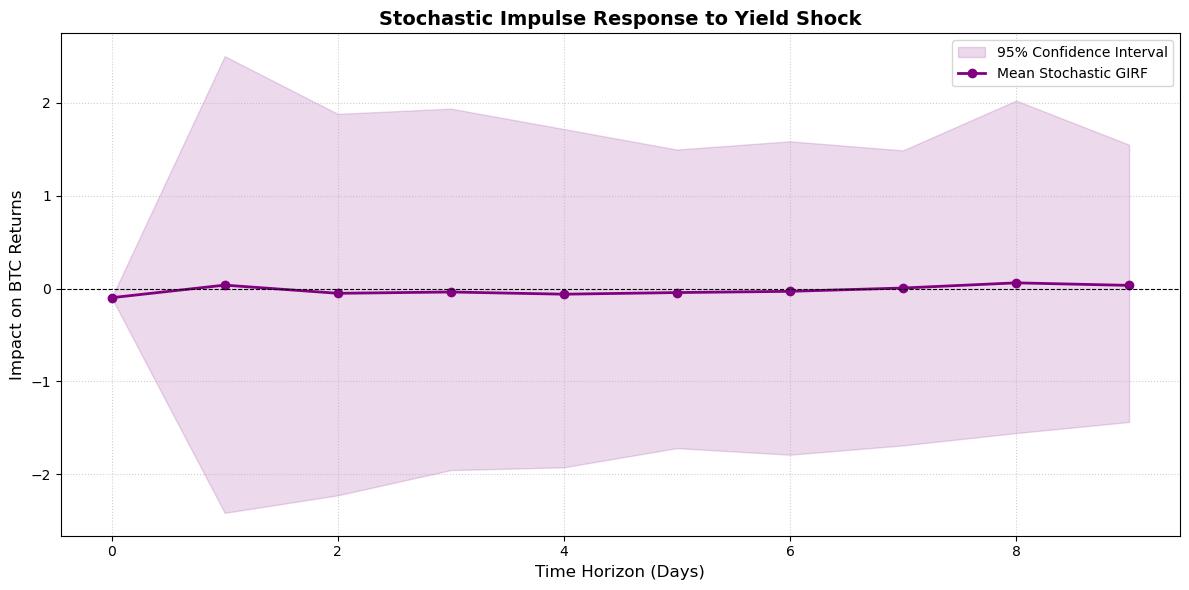

In [63]:
def simulate_kvd_girf(res, shock=1.0, horizon=10, n_sims=1000):
    p_matrix = res.regime_transition
    mu = [res.params['const[0]'], res.params['const[1]']]
    beta = [res.params['x1[0]'], res.params['x1[1]']]
    sigma = [np.sqrt(res.params['sigma2[0]']), np.sqrt(res.params['sigma2[1]'])]
    
    girf_data = np.zeros((n_sims, horizon))
    
    for i in range(n_sims):
        current_regime = 1
        path = np.zeros(horizon)
        path[0] = beta[current_regime] * shock
        
        for t in range(1, horizon):
            probs = np.array(p_matrix[:, current_regime]).flatten()
            current_regime = np.random.choice([0, 1], p=probs)
            path[t] = mu[current_regime] + np.random.normal(0, sigma[current_regime])
        
        girf_data[i, :] = path
        
    return girf_data

girf_data = simulate_kvd_girf(res)

kvd_path = np.mean(girf_data, axis=0)
lower_bound = np.percentile(girf_data, 5, axis=0)
upper_bound = np.percentile(girf_data, 95, axis=0)

plt.figure(figsize=(12, 6))
x_axis = np.arange(len(kvd_path))

plt.fill_between(x_axis, lower_bound, upper_bound, color='purple', alpha=0.15, label='95% Confidence Interval')
plt.plot(x_axis, kvd_path, color='purple', marker='o', markersize=6, linewidth=2, label='Mean Stochastic GIRF')

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Stochastic Impulse Response to Yield Shock", fontsize=14, fontweight='bold')
plt.xlabel("Time Horizon (Days)", fontsize=12)
plt.ylabel("Impact on BTC Returns", fontsize=12)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

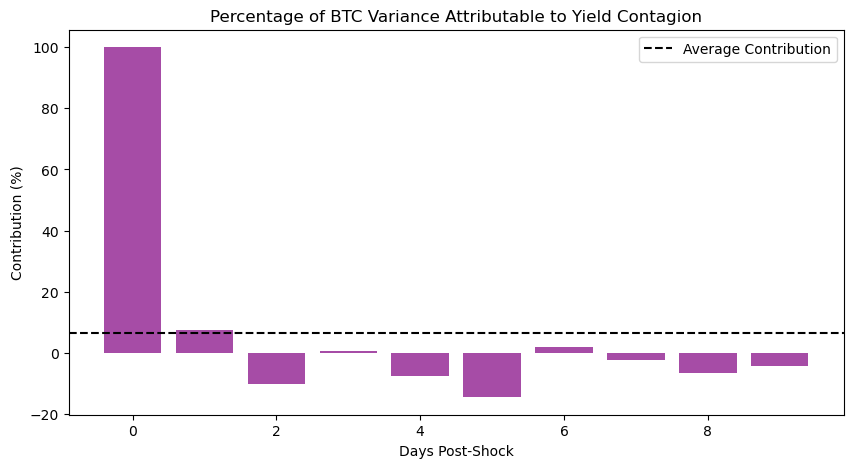

In [ ]:
#shock-case
girf_shock = simulate_kvd_girf(res, shock=1.0) 

#null-case
girf_null = simulate_kvd_girf(res, shock=0.0)

#calculate the Variance of the paths
var_shock = np.var(girf_shock, axis=0)
var_null = np.var(girf_null, axis=0)

#calc yield shock contribution
contagion_ratio = (var_shock - var_null) / var_shock

# Plotting the results
plt.figure(figsize=(10, 5))
plt.bar(range(len(contagion_ratio)), contagion_ratio * 100, color='purple', alpha=0.7)
plt.axhline(np.mean(contagion_ratio * 100), color='black', linestyle='--', label='Average Contribution')
plt.title("Percentage of BTC Variance Attributable to Yield Shock")
plt.xlabel("Days Post-Shock")
plt.ylabel("Contribution (%)")
plt.legend()
plt.show()